# Baseline JIT Defect Prediction Experiment

This notebook demonstrates a basic Just-In-Time (JIT) defect prediction experiment using the KG-Commit framework.

## Setup and Imports

In [1]:
import sys
import time
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

sys.path.append(os.path.join(os.getcwd(), '..', '..'))

In [2]:
from kg_commit.data.dataset import CSVCommitDataset
from kg_commit.data.preprocess import SimplePreprocessor
from kg_commit.data.stream import CommitStream
from kg_commit.evaluation.evaluator import Evaluator
from kg_commit.model.online_model import OnlineModel
from kg_commit.training.incremental_trainer import IncrementalTrainer
from kg_commit.utils.config import Config, PROJECT_ROOT
from kg_commit.persistence.serializer import JSONSerializer
from kg_commit.utils.logging import SimpleLogger

In [3]:
# Load configuration
config_path = PROJECT_ROOT / 'experiments' / 'configs' / 'default.yaml'
config = Config.from_yaml(config_path)
logger = SimpleLogger()

# Extract config values
data_path = config.get("data.test_path")
label_column = config.get("preprocessing.label_column")
timestamp_column = config.get("data.timestamp_column")
window_size = config.get("streaming.window_size")
window_step = config.get("streaming.window_step")
output_dir = Path(config.get("output.results_dir", "outputs/results"))
output_dir.mkdir(parents=True, exist_ok=True)

print("Configuration loaded:")
print(f"  Data path: {data_path}")
print(f"  Label column: {label_column}")
print(f"  Window size: {window_size}")
print(f"  Output directory: {output_dir}")

Configuration loaded:
  Data path: D:\Projects\kgcommit\data\apachejit\apachejit_test_small.csv
  Label column: buggy
  Window size: 50
  Output directory: D:\Projects\kgcommit\outputs\results


## Data Loading

Load the dataset and examine its structure.

In [4]:
# Load the dataset using config
dataset = CSVCommitDataset(source=data_path, label_column=label_column, timestamp_column=timestamp_column)
commits = dataset.load()

print(f"Loaded {len(commits)} commits")
print(f"Metadata: {dataset.get_metadata()}")

# Display first few commits
for i, commit in enumerate(commits[:3]):
    print(f"Commit {i+1}: {commit}")

Loaded 7526 commits
Metadata: {'rows': 7526, 'columns': ['commit_id', 'project', 'buggy', 'fix', 'year', 'author_date', 'commit_text', 'la', 'ld', 'nf', 'nd', 'ns', 'ent', 'ndev', 'age', 'nuc', 'aexp', 'arexp', 'asexp']}
Commit 1: Commit(id=d41245ca56ab743a142508bfd4c5bc2c8c095674, project=apache/hadoop, buggy=False)
Commit 2: Commit(id=d65b373ec4b65b3b1cf7bb7ba7f59b9a9f088de9, project=apache/hadoop, buggy=False)
Commit 3: Commit(id=b1fa06aacb360239b30f1855cb91d6399211a37f, project=apache/hadoop, buggy=False)


## Preprocessing

Set up the preprocessor and stream the data into windows.

In [5]:
# Set up preprocessing from config
preprocessor = SimplePreprocessor(
    label_column=label_column, 
    include_text=config.get("preprocessing.include_text", True)
)

# Create data stream from config
stream = CommitStream(commits, window_size=window_size, step=window_step)

print(f"Preprocessing configured with window_size={window_size}, step={window_step}")
print("Processing first window...")
first_window = next(iter(stream))
print(f"First window: {first_window}")

# Preprocess the window
preprocessed_window = preprocessor.transform_window(first_window)
print(f"Preprocessed window shape: {preprocessed_window.get_features().shape if preprocessed_window.get_features() is not None else 'None'}")
print(f"Labels shape: {preprocessed_window.get_labels().shape}")

Preprocessing configured with window_size=50, step=50
Processing first window...
First window: Window(size=50, time=(1434391442.0 → 1479119398.0), preprocessed=False)
Preprocessed window shape: (50, 2)
Labels shape: (50,)


## Model Training and Evaluation

Set up the model, evaluator, and trainer, then run the experiment.

In [6]:
# Set up model and evaluator from config
model_classes = config.get("model.classes", [0, 1])
model = OnlineModel(classes=model_classes)
evaluator = Evaluator()

# Create trainer
trainer = IncrementalTrainer(model=model, preprocessor=preprocessor, evaluator=evaluator)

# Reset stream for full experiment
stream = CommitStream(commits, window_size=window_size, step=window_step)

# Run the experiment
print(f"Running experiment with {len(commits)} commits | {window_size} window size | {window_step} step size")

time.sleep(0.5)
# Calculate total windows based on stream logic
total_windows = (len(commits) - window_size) // window_step + 1

# Run the experiment
results = []
for index, (window, preds) in enumerate(trainer.run(stream), start=1):
    # Use the pre-calculated total_windows instead of list(stream)
    if index % max(1, total_windows // 4) == 0 or index == 1:
        logger.log_window(window)
    results.append((window, preds))

# Get final evaluation
summary = evaluator.summarize()
print("\n" + "="*50)
print("Final Results:")
print("="*50)
print(f"Accuracy: {summary['accuracy']:.4f}")
print(f"Precision: {summary['precision']:.4f}")
print(f"Recall: {summary['recall']:.4f}")
print(f"F1 Score: {summary['f1']:.4f}")
print("\nClassification Report:")
print(summary['report'])

Running experiment with 7526 commits | 50 window size | 50 step size


2026-05-04 20:31:42,935 - INFO - Window: size=50, time=(1434391442.0 → 1479119398.0)
2026-05-04 20:31:43,021 - INFO - Window: size=50, time=(1502475493.0 → 1503276753.0)
2026-05-04 20:31:43,103 - INFO - Window: size=50, time=(1525978494.0 → 1526586430.0)
2026-05-04 20:31:43,181 - INFO - Window: size=50, time=(1552532834.0 → 1553215012.0)
2026-05-04 20:31:43,252 - INFO - Window: size=50, time=(1575375752.0 → 1575882687.0)



Final Results:
Accuracy: 0.7289
Precision: 0.2632
Recall: 0.2272
F1 Score: 0.2439

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83      6078
           1       0.26      0.23      0.24      1448

    accuracy                           0.73      7526
   macro avg       0.54      0.54      0.54      7526
weighted avg       0.71      0.73      0.72      7526



## Saving Results

In [7]:
# Save results using config
serializer = JSONSerializer()
results_data = {
    "experiment_name": config.get("experiment.name"),
    "description": config.get("experiment.description"),
    "data_path": str(data_path),
    "window_size": window_size,
    "window_step": window_step,
    "num_windows": len(results),
    "summary": summary
}
results_file = output_dir / "baseline_results.json"
serializer.save(results_data, str(results_file))
print(f"Results saved to {results_file}")

Results saved to D:\Projects\kgcommit\outputs\results\baseline_results.json


## Visualization

Plot some results.

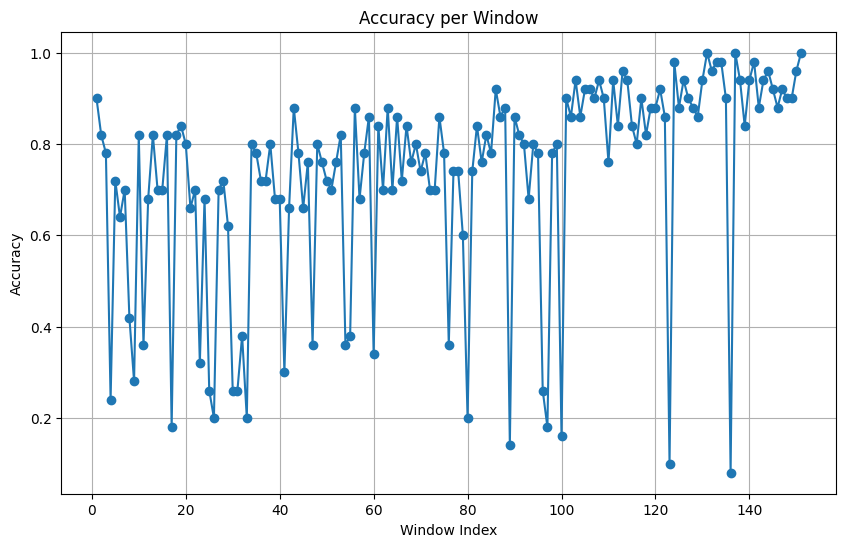

Average accuracy across windows: 0.7298


In [8]:
# Simple visualization of predictions vs actual
window_indices = list(range(1, len(results) + 1))
accuracies = []

for window, preds in results:
    y_true = window.get_labels()
    acc = (preds == y_true).mean()
    accuracies.append(acc)

plt.figure(figsize=(10, 6))
plt.plot(window_indices, accuracies, marker='o')
plt.title('Accuracy per Window')
plt.xlabel('Window Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

print(f"Average accuracy across windows: {sum(accuracies)/len(accuracies):.4f}")